# Bar inventory forecasting and par recommendations

**Kristalball take-home | reproducible notebook**

The decision is made for each **bar + brand**: forecast usage, choose a target stock (par), and flag replenishment. Units are millilitres throughout. Keep the CSV beside this notebook. In JupyterLab, use Kernel > Restart Kernel and Run All Cells; running a later cell alone after a fresh kernel skips its inputs. The dataset is a public Google Sheet linked in the assessment; a downloaded snapshot is included in the repository for reproducibility. This is a prototype, not an automated purchase-order system. No orders are placed.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA = Path('bar_inventory_movements.csv')
assert DATA.exists(), 'Run from repository root (or change DATA to the CSV path).'
raw = pd.read_csv(DATA)
raw['timestamp'] = pd.to_datetime(raw['Date Time Served'], format='%m/%d/%Y %H:%M', errors='raise')
raw = raw.sort_values(['Bar Name','Brand Name','timestamp'], kind='stable').reset_index(drop=True)
KEY = ['Bar Name', 'Brand Name']
NUM = ['Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']
print(f'{len(raw):,} rows | {raw["Bar Name"].nunique()} bars | {raw["Brand Name"].nunique()} brands | '
      f'{raw.timestamp.min()} through {raw.timestamp.max()}')
print('Nulls:', raw.isna().sum().to_dict())
display(raw.head())

6,575 rows | 6 bars | 16 brands | 2023-01-01 10:07:00 through 2024-01-01 22:46:00
Nulls: {'Date Time Served': 0, 'Bar Name': 0, 'Alcohol Type': 0, 'Brand Name': 0, 'Opening Balance (ml)': 0, 'Purchase (ml)': 0, 'Consumed (ml)': 0, 'Closing Balance (ml)': 0, 'timestamp': 0}


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),timestamp
0,1/2/2023 21:05,Anderson's Bar,Vodka,Absolut,1.309920e+03,0.0,118.62,1.191300e+03,2023-01-02 21:05:00
1,1/5/2023 10:10,Anderson's Bar,Vodka,Absolut,1.191300e+03,0.0,463.20,7.281000e+02,2023-01-05 10:10:00
2,1/6/2023 22:13,Anderson's Bar,Vodka,Absolut,7.281000e+02,0.0,453.02,2.750800e+02,2023-01-06 22:13:00
3,1/8/2023 19:18,Anderson's Bar,Vodka,Absolut,2.750800e+02,0.0,275.08,1.710000e-13,2023-01-08 19:18:00
4,1/11/2023 21:44,Anderson's Bar,Vodka,Absolut,1.710000e-13,0.0,0.00,1.710000e-13,2023-01-11 21:44:00


## 1. Audit the movement log

`Opening + purchase - consumed = closing` should hold. Each row is a movement observation, **not necessarily a day's sales**. There is usually one observation for a bar-brand on a date, and several days can pass between records. Previous closing generally matches next opening; that supports treating a row's consumption as usage over the time since the previous observation, but it does not prove that interpretation. Verify this with the hotel before production. Do not fill unlogged dates with zero sales.

Duplicate full rows: 0
Rows with balance mismatch > 1 ml: 86
Transitions with opening gap > 1 ml: 129
Interval days, median / 90th pct: 3.8618055555555557 11.274305555555555


,Bar Name,Brand Name,timestamp,balance_error_ml
283,Anderson's Bar,Captain Morgan,2023-03-13 20:08:00,-3.05
352,Anderson's Bar,Coors,2023-02-17 13:20:00,1.23
407,Anderson's Bar,Grey Goose,2023-01-18 10:37:00,-3.25
417,Anderson's Bar,Grey Goose,2023-03-03 18:20:00,4.73
418,Anderson's Bar,Grey Goose,2023-03-06 13:36:00,-7.56


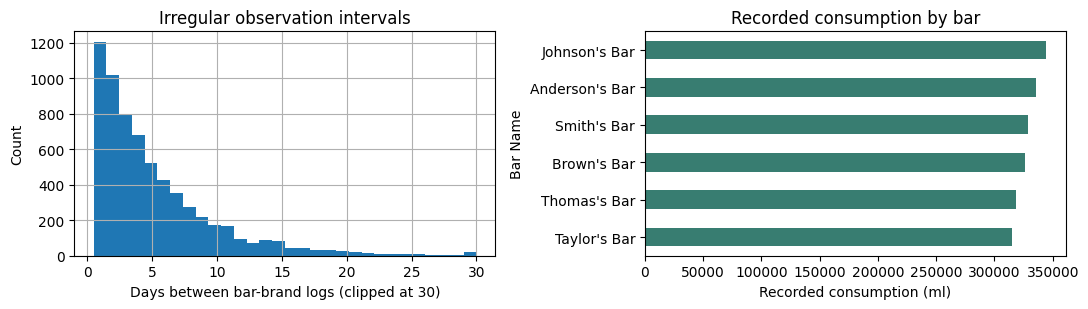

In [2]:
audit = raw.copy()
audit['balance_error_ml'] = (audit['Opening Balance (ml)'] + audit['Purchase (ml)']
                             - audit['Consumed (ml)'] - audit['Closing Balance (ml)'])
audit['previous_close_ml'] = audit.groupby(KEY)['Closing Balance (ml)'].shift()
audit['opening_gap_ml'] = audit['Opening Balance (ml)'] - audit['previous_close_ml']
audit['elapsed_days'] = audit.groupby(KEY)['timestamp'].diff().dt.total_seconds() / 86400
print('Duplicate full rows:', int(audit.duplicated(subset=raw.columns).sum()))
print('Rows with balance mismatch > 1 ml:', int((audit.balance_error_ml.abs() > 1).sum()))
print('Transitions with opening gap > 1 ml:', int((audit.opening_gap_ml.abs() > 1).sum()))
print('Interval days, median / 90th pct:', audit.elapsed_days.median(), audit.elapsed_days.quantile(.9))
display(audit.loc[audit.balance_error_ml.abs()>1, KEY + ['timestamp','balance_error_ml']].head())
fig, ax = plt.subplots(1,2,figsize=(11,3.2))
audit['elapsed_days'].dropna().clip(upper=30).hist(bins=30,ax=ax[0]); ax[0].set(xlabel='Days between bar-brand logs (clipped at 30)', ylabel='Count', title='Irregular observation intervals')
raw.groupby('Bar Name')['Consumed (ml)'].sum().sort_values().plot.barh(ax=ax[1],color='#387d71'); ax[1].set(xlabel='Recorded consumption (ml)', title='Recorded consumption by bar')
plt.tight_layout(); plt.show()

## 2. Build the target without zero-filling missing dates

For each bar-brand after its first row, `rate = consumed_ml / elapsed_days`. This assumes consumption belongs to the interval ending at the timestamp. The first row has no known start time and is excluded from evaluation. Keep positive elapsed intervals, nonnegative usage, and flag records with a material accounting discrepancy. We retain discrepant records in the forecast, because small accounting offsets are common, but they must be investigated before operational use.

In [3]:
obs = audit.loc[(audit.elapsed_days > 0) & (audit['Consumed (ml)'] >= 0)].copy()
obs['rate_ml_day'] = obs['Consumed (ml)'] / obs.elapsed_days
print('Intervals with known duration:', len(obs), '| groups:', obs.groupby(KEY).ngroups)
print('Rate ml/day percentiles:', obs.rate_ml_day.quantile([.5,.9,.99]).round(1).to_dict())
# Prevent an unexpectedly short interval from dominating recent estimates: rate caps are learned from training only.
train_end = pd.Timestamp('2023-10-01')
valid_end = pd.Timestamp('2023-11-15')
train = obs[obs.timestamp < train_end]
valid = obs[(obs.timestamp >= train_end) & (obs.timestamp < valid_end)]
test = obs[obs.timestamp >= valid_end]
assert len(train) and len(valid) and len(test)
rate_cap = float(train.rate_ml_day.quantile(.99))
obs['capped_rate'] = obs.rate_ml_day.clip(upper=rate_cap)
print('Train / validation / test:', len(train), len(valid), len(test), '| train-only rate cap:',round(rate_cap,1),'ml/day')

Intervals with known duration: 6479 | groups: 96
Rate ml/day percentiles: {0.5: 67.7, 0.9: 308.9, 0.99: 704.1}
Train / validation / test: 4827 800 852 | train-only rate cap: 709.8 ml/day


## 3. One-step interval forecast and chronological selection

Compare three transparent methods. **Lifetime** uses all previous intervals' total consumption divided by their total days. **Recent six** takes the duration-weighted mean of the last six intervals. **Shrunk recent** averages recent with the lifetime rate, weighted by the last six intervals' elapsed days versus a 30-day prior. All use only data **strictly before** the target observation. Selection uses validation MAE, then the untouched test period assesses the selected model. Rolling one-step forecasts assume the last real observation has arrived before forecasting the next; this is not a fixed multi-week forecast.

Validation MAE (ml / observed interval):


,MAE
method,
lifetime,245.79
shrunk6,248.38
recent6,276.30


Selected: lifetime


,n,MAE_ml,WAPE_pct,bias_ml
method,,,,
lifetime,852.0,247.80,82.97,-1.74
recent6,852.0,281.81,94.36,-44.23
shrunk6,852.0,254.32,85.16,-12.95


Chosen method test metrics: {'n': 852.0, 'MAE_ml': 247.8, 'WAPE_pct': 82.97, 'bias_ml': -1.74}


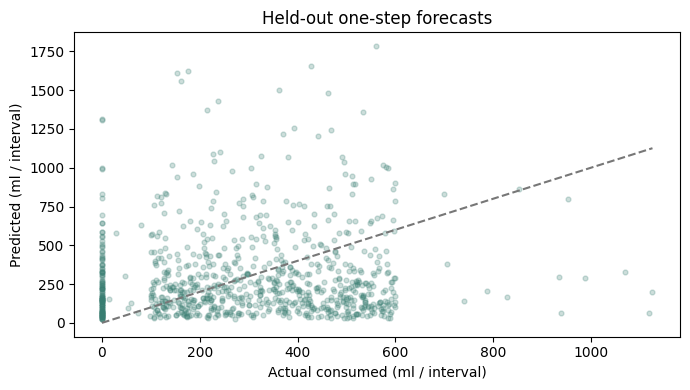

In [4]:
# Forecasts depend on the cleaned intervals and rate cap built in section 2.
# Give a useful instruction rather than a NameError if this cell is run first.
if not {'obs', 'rate_cap', 'train_end', 'valid_end', 'KEY', 'np', 'pd', 'plt'}.issubset(globals()):
    raise RuntimeError('Run the notebook from the top: Kernel > Restart Kernel and Run All Cells. Keep bar_inventory_movements.csv beside the notebook.')

def walk_forward(df, rate_cap, methods=('lifetime','recent6','shrunk6')):
    records = []
    for (bar,brand), g in df.groupby(KEY, sort=False):
        g = g.sort_values('timestamp')
        hist = []
        for _, row in g.iterrows():
            days = row['elapsed_days']
            if hist:
                past = hist[-6:]
                lifetime = sum(c for d,c in hist) / sum(d for d,c in hist)
                recent_days = sum(d for d,c in past)
                recent = sum(c for d,c in past) / recent_days
                rates = {'lifetime':lifetime, 'recent6':recent,
                         'shrunk6':(recent * recent_days + lifetime * 30) / (recent_days + 30)}
                for name in methods:
                    records.append((bar,brand,row['timestamp'],days,row['Consumed (ml)'],name,
                                    max(0., rates[name] * days)))
            # Cap interval's rate using threshold learned before validation/test; preserve elapsed days.
            hist.append((days, min(row['Consumed (ml)'], rate_cap * days)))
    return pd.DataFrame(records,columns=KEY+['timestamp','elapsed_days','actual_ml','method','pred_ml'])

pred = walk_forward(obs, rate_cap)
pred['abs_error_ml'] = (pred.actual_ml - pred.pred_ml).abs()
validation = pred[(pred.timestamp >= train_end) & (pred.timestamp < valid_end)]
test_preds = pred[pred.timestamp >= valid_end]
choice = validation.groupby('method').abs_error_ml.mean().sort_values()
selected = choice.index[0]
print('Validation MAE (ml / observed interval):'); display(choice.round(2).to_frame('MAE'))
print('Selected:', selected)

def metrics(frame):
    err = frame.actual_ml-frame.pred_ml
    return pd.Series({'n':len(frame), 'MAE_ml':err.abs().mean(), 'WAPE_pct':100*err.abs().sum()/frame.actual_ml.sum()
                      if frame.actual_ml.sum() else np.nan, 'bias_ml':err.mean()})
summary = test_preds.groupby('method').apply(metrics, include_groups=False).round(2)
display(summary)
selected_test = test_preds[test_preds.method==selected]
assert len(selected_test)>0 and np.isfinite(selected_test.pred_ml).all()
print('Chosen method test metrics:',metrics(selected_test).round(2).to_dict())
fig, ax=plt.subplots(figsize=(7,4)); ax.scatter(selected_test.actual_ml,selected_test.pred_ml,alpha=.25,s=12,color='#387d71'); ax.plot([0,selected_test.actual_ml.max()],[0,selected_test.actual_ml.max()],'--',color='#777');ax.set(xlabel='Actual consumed (ml / interval)',ylabel='Predicted (ml / interval)',title='Held-out one-step forecasts');plt.tight_layout();plt.show()

## 4. Turn forecasts into inventory recommendations

Use a configurable 2-day supplier lead plus 1-day review cycle (3 days of protection), a **20% provisional buffer**, and 100 ml rounding for a simple par. These are scenario assumptions, **not learned business facts or a calibrated 95% service level**. Replenishment is `max(0, par - on_hand - on_order)`, where on_order is assumed zero because the dataset does not track open orders. Most recent closing balance acts as an illustrative on-hand snapshot, not a current stock count. Do **not** place orders from these stale 2024 values.

In [5]:
LEAD_DAYS, REVIEW_DAYS, BUFFER, ROUND_ML = 2,1,.20,100

def estimate_daily(hist, model, cap):
    days = hist.elapsed_days.to_numpy(float)
    usage = np.minimum(hist['Consumed (ml)'].to_numpy(float), cap*days)
    lifetime = usage.sum()/days.sum()
    recent_days = days[-6:].sum()
    recent = usage[-6:].sum()/recent_days
    return {'lifetime':lifetime,'recent6':recent,
            'shrunk6':(recent*recent_days + lifetime*30)/(recent_days+30)}[model]

rows=[]
for (bar,brand), group in obs.groupby(KEY):
    rate=estimate_daily(group.sort_values('timestamp'),selected,rate_cap)
    last=raw[(raw['Bar Name']==bar)&(raw['Brand Name']==brand)].sort_values('timestamp').iloc[-1]
    target=rate*(LEAD_DAYS+REVIEW_DAYS)*(1+BUFFER)
    par=math.ceil(target/ROUND_ML)*ROUND_ML
    on_hand=float(last['Closing Balance (ml)'])
    rows.append((bar,brand,round(rate,1),round(rate*7,1),par,round(on_hand,1),max(0,math.ceil((par-on_hand)/ROUND_ML)*ROUND_ML),last.timestamp))
recs=pd.DataFrame(rows,columns=KEY+['forecast_ml_day','forecast_next_7d_ml','par_ml','last_logged_close_ml','suggested_order_ml','last_logged_at'])
recs=recs.sort_values(['Bar Name','Brand Name']).reset_index(drop=True)
assert len(recs)==96 and (recs.par_ml>=0).all() and (recs.suggested_order_ml>=0).all()
display(recs.head(12))
print('Illustrative items under par:',int((recs.suggested_order_ml>0).sum()),'of',len(recs))
recs.to_csv('illustrative_recommendations.csv',index=False)

,Bar Name,Brand Name,forecast_ml_day,forecast_next_7d_ml,par_ml,last_logged_close_ml,suggested_order_ml,last_logged_at
0,Anderson's Bar,Absolut,36.4,255.1,200,0.0,200,2023-12-25 10:16:00
1,Anderson's Bar,Bacardi,71.3,499.2,300,108.6,200,2023-12-31 19:02:00
2,Anderson's Bar,Barefoot,73.2,512.6,300,7321.3,0,2023-12-30 21:46:00
3,Anderson's Bar,Budweiser,28.2,197.2,200,0.0,200,2023-12-26 22:58:00
4,Anderson's Bar,Captain Morgan,77.5,542.5,300,8383.2,0,2023-12-19 17:48:00
5,Anderson's Bar,Coors,57.6,403.1,300,2146.0,0,2024-01-01 21:03:00
6,Anderson's Bar,Grey Goose,66.5,465.8,300,0.0,300,2023-12-30 15:59:00
7,Anderson's Bar,Heineken,47.3,330.9,200,182.0,100,2023-12-31 10:10:00
8,Anderson's Bar,Jack Daniels,59.5,416.7,300,3995.1,0,2024-01-01 18:34:00
9,Anderson's Bar,Jameson,63.1,441.6,300,2688.4,0,2023-12-30 18:37:00


Illustrative items under par: 17 of 96


## 5. Simulate how a manager uses the system

Illustrative **single-brand, seven-day scenario**: start at an assumed 150 ml physical count; review stock each day, place an order when inventory position is below par, receive it after two days. Daily usage is set to the predicted mean, except a 1.5× weekend-like spike on days 5 and 6. This is a synthetic scenario, not a measured stockout reduction or a historical policy test. The practical workflow also requires a live count, confirmed supplier lead times, open orders, case sizes, and manager approval.

In [6]:
example=recs.sort_values('forecast_ml_day',ascending=False).iloc[0]
par=float(example.par_ml); mean=float(example.forecast_ml_day)
stock=150.; pending=[]; log=[]; lost_total=0.
for day in range(1,8):
    arrivals=sum(q for due,q in pending if due==day)
    pending=[(due,q) for due,q in pending if due>day]
    stock+=arrivals
    position=stock+sum(q for _,q in pending)
    order=max(0,math.ceil((par-position)/ROUND_ML)*ROUND_ML)
    if order: pending.append((day+LEAD_DAYS,order))
    demand=mean*(1.5 if day in (5,6) else 1.)
    served=min(stock,demand); lost=demand-served
    stock-=served;lost_total+=lost
    log.append((day,round(arrivals),round(order),round(demand),round(served),round(lost),round(stock)))
scenario=pd.DataFrame(log,columns=['day','arrived_ml','ordered_ml','demand_ml','served_ml','unserved_ml','closing_ml'])
print('Scenario:',example['Bar Name'],'/',example['Brand Name'],'| par:',int(par),'ml | daily forecast:',round(mean),'ml')
display(scenario)
print('Synthetic unserved demand (ml):',round(lost_total),'| not an observed business outcome')

Scenario: Taylor's Bar / Grey Goose | par: 300 ml | daily forecast: 79 ml


,day,arrived_ml,ordered_ml,demand_ml,served_ml,unserved_ml,closing_ml
0,1,0,200,79,79,0,71
1,2,0,100,79,71,8,0
2,3,200,0,79,79,0,121
3,4,100,100,79,79,0,142
4,5,0,100,118,118,0,24
5,6,100,100,118,118,0,6
6,7,100,100,79,79,0,27


Synthetic unserved demand (ml): 8 | not an observed business outcome


## 6. Limits and handoff

- Intermittent logs and possible stockouts mean **recorded consumption may be censored demand**; higher sales cannot be recovered from this sheet. No occupancy, event, price, supplier lead-time, costs, sales receipts, or confirmed inventory count are provided.
- Records with balance mismatch or discontinuous opening require reconciliation; cap extreme daily rates only using training statistics. Train/validation/test splits are chronological, but one-step estimates update after each actual event. The data ends on 1 Jan 2024, so recommendations are **examples, not live reorder instructions**.
- For production, ingest daily point-of-sale sales, receipts, waste and counts; resolve returns and transfers; log stockouts; retrain on new data; forecast over lead-time plus review horizon; calibrate par to the actual service-cost tradeoff. Monitor forecast bias/WAPE by bar-brand, stockout days, aged inventory, data gaps and overrides. Get a manager's approval before any purchase order.
- Run `pytest -q` for sanity checks. This notebook writes `illustrative_recommendations.csv` when executed. See `README.md` for reproducibility and `report.pdf` for the short assessment answers.